# Библиотеки

In [2]:
!pip install huggingface

In [3]:
!pip install datasets

# Подбор наборов данных

## [Vikhrmodels/russian_physics](https://huggingface.co/datasets/Vikhrmodels/russian_physics)

<u>Кол-во строк:</u> 98

* задачи по физике на русском языке, преимущественно олимпиадного и углублённого школьного уровня
* ориентирован на reasoning (пошаговое решение)
* качественная формулировка ответов, подойдёт для того, чтобы моделька могла именно "думать"


## [Vikhrmodels/russian_math](https://huggingface.co/datasets/Vikhrmodels/russian_math)

<u>Кол-во строк:</u> 199

* задачи по математике разного уровеня
* ориентирован на reasoning (пошаговое решение)
* понятное объяснение решений

## [Vikhrmodels/sdamgia](https://huggingface.co/datasets/Vikhrmodels/sdamgia)

<u>Рвзмер:</u>
1) Split 1 'mathb' - *2.5k*
2) Split 2 'math'  - *7.2k*

_____

* большое кол-во задач
* структурированные вопросы
* реальные экзаменационные задания
* есть изображения

**ПРОБЛЕМЫ:**

- нет объяснений
- => только на таких данных модель не сможет научиться "размышлять самостоятельно"

___

для использования этого набора данных необходимо добавить инструкции, + лучше смешивать с reasoning-датасетами

## [lighteval/QazUNTv2](https://huggingface.co/datasets/lighteval/QazUNTv2/viewer/ru)

<u>Рвзмер:</u>
1) Subset 1 'en' - *854*
2) Subset 2 'ru'  - *850*          -----------------> то, что подходит под задачу

_____

* датасет математических задач, использовавшийся для оценки моделей
* ориентирован на проверку reasoning
* может использоваться и для обучения и для валидации 

## [mizinovmv/ru_codefeedback](https://huggingface.co/datasets/mizinovmv/ru_codefeedback)

<u>Кол-во строк:</u> 107k

* датасет по проге, включает в себя: python, sql. php, javascript, html и тд
* содержит задачи разного вида

## [evilfreelancer/MATH-500-Russian](https://huggingface.co/datasets/evilfreelancer/MATH-500-Russian)

<u>Кол-во строк:</u> 500

* сложные мат. задачи
* ориентирован на reasoning

## [ai-bond/ru-alpaca-math](https://huggingface.co/datasets/ai-bond/ru-alpaca-math)

<u>Рвзмер:</u>
1) Split 1 'train' - *9,23k*
2) Split 2 'test'  - *7.02k*

______

* Instruction-датасет в стиле Alpaca, ориентированный на математические задачи
* разнообразные формулировки заданий

**ПРОБЛЕМЫ:**

- менее строгий стиль ответов
- возможен шум?? (синтетика)
- хорошо подойдёт для дополнения, но не как основной источник обучения

## [s85io/math-logic-ru](https://huggingface.co/datasets/s85io/math-logic-ru)

<u>Рвзмер:</u>
1) Split 1 'train' - *3,96k*
2) Split 2 'validation'  - *441*

____

* датасет по логике и математическим рассуждениям
* задачи на логическое мышление, выводы, формальные рассуждения
* усиливает у модели способность рассуждать  

_____________________________

## Доп. :

* Нужно, чтобы у всех формул был ЕДИНЫЙ формат, иначе модель будет очень плохо  их генерировать *=> необходимо привести все формулы в датасете к нужному формату* 

**LaTeX** - стандартный формат для таких записей

* Нужно добавить/переделать инструкции (где-то их нет, где-то они возможно не очень качественны)

* Могут быть проблемы с токенизацией спец. символов

# Разбор датасетов

In [13]:
from datasets import load_dataset
import matplotlib.pyplot as plt

## [mizinovmv/ru_codefeedback](https://huggingface.co/datasets/mizinovmv/ru_codefeedback)

In [5]:
ds_code = load_dataset('mizinovmv/ru_codefeedback')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [6]:
ds_code

DatasetDict({
    train: Dataset({
        features: ['query', 'resource', 'lang', 'ru_query', 'answer'],
        num_rows: 107279
    })
})

In [7]:
ds_code = ds_code['train'].to_pandas()

In [8]:
ds_code

,query,resource,lang,ru_query,answer
0,Create a nested loop to print every combinatio...,evolinstruct,python,Создайте вложенный цикл для вывода каждой комб...,"```python\ndef print_combinations():\n """"""\..."
1,Write a function to find the number of distinc...,evolinstruct,python,Создайте функцию для определения количества ра...,"К сожалению, предоставленный ""корректный"" код ..."
2,Write code that removes spaces and punctuation...,evolinstruct,python,"Напишите код, который удаляет пробелы и знаки ...","Ниже приведен пример кода на Python, который у..."
3,Write a function that checks if a given number...,evolinstruct,python,"Напишите функцию, которая проверяет, является ...",```python\nimport math\n\ndef check_prime(numb...
4,Write a method for a string class which replac...,evolinstruct,python,"Напишите метод для класса строк, который замен...",```python\nimport re\n\nclass String:\n def...
...,...,...,...,...,...
107274,Write a function that takes an array of intege...,evolinstruct,python,"Напишите функцию, которая принимает массив цел...",```python\ndef count_and_sum_even_numbers_divi...
107275,Explain the concept of bitwise AND operation a...,evolinstruct,python,Объясните концепцию побитовой операции И и при...,**Побитовая операция И (Bitwise AND)**\n\nПоби...
107276,Write a code to show the rating of a movie bas...,evolinstruct,python,Напишите код для отображения рейтинга фильма н...,```python\ndef calculate_rating(rev_comments):...
107277,Implement a binary search algorithm in Python ...,evolinstruct,python,Реализуйте алгоритм бинарного поиска на Python...,## Бинарный поиск в Python\n\n### Реализация а...


In [9]:
ds_code.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107279 entries, 0 to 107278
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   query     107279 non-null  object
 1   resource  107279 non-null  object
 2   lang      107279 non-null  object
 3   ru_query  107279 non-null  object
 4   answer    107279 non-null  object
dtypes: object(5)
memory usage: 4.1+ MB


In [10]:
ds_code['lang'].unique()

array(['python', 'sql', 'jsx', 'cpp', 'javascript', 'html', 'java', 'php',
       'ruby', 'shell', 'json', 'c', 'csharp', 'css', 'dockerfile', 'r',
       'http', 'yaml', 'matlab', 'haskell', 'graphql', 'swift', 'perl',
       'delphi', 'xml', 'go', 'scala', 'rust', 'assembly', 'vba', 'julia',
       'f#', 'sas', 'typescript', 'regex', 'batch', 'latex', 'scss',
       'objective-c', 'mongo', 'powershell', 'jsp', 'cmake', 'prolog',
       'lua', 'makefile', 'mongodb', 'vb', 'kotlin', 'pascal', 'objc',
       'xslt', 'applescript', 'sass', 'fortran', 'tsx', 'cuda',
       'protobuf', 'verilog', 'hcl', 'racket', 'postgresql', 'llvm',
       'groovy', 'sqlite'], dtype=object)

In [11]:
ds_code['lang'].value_counts()

,count
lang,
python,92956
javascript,2395
java,2214
sql,1677
cpp,1511
...,...
racket,1
postgresql,1
llvm,1


In [12]:
print(ds_code['lang'].value_counts(normalize = True))

lang
python        0.866488
javascript    0.022325
java          0.020638
sql           0.015632
cpp           0.014085
                ...   
racket        0.000009
postgresql    0.000009
llvm          0.000009
groovy        0.000009
sqlite        0.000009
Name: proportion, Length: 65, dtype: float64


python - почти 85% от всего датасета

In [ ]:
ds_code['lang'].value_counts().head(15) # топ 15 по кол-ву

,count
lang,
python,92956
javascript,2395
java,2214
sql,1677
cpp,1511
rust,1051
swift,903
csharp,844
shell,771


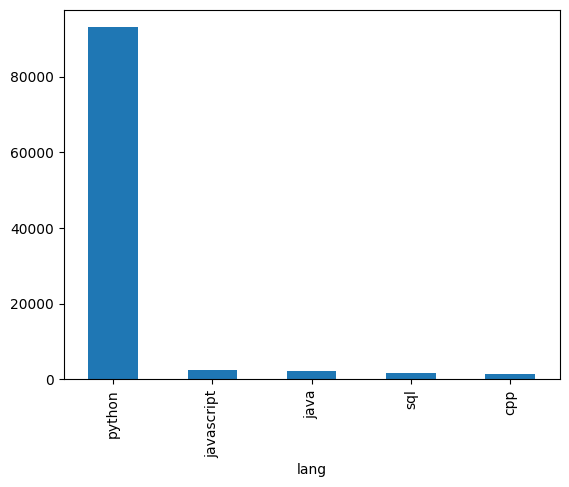

In [ ]:
# визуализация топ 5 по кол-ву
ds_code['lang'].value_counts().head(5).plot(kind='bar')
plt.show()

In [22]:
ds_code = ds_code[ds_code['lang'].isin(['python', 'javascript', 'java', 'sql', 'html'])]

___

In [25]:
ds_code['resource'].value_counts()

,count
resource,
wizardcoder,37522
evolinstruct,31631
magicoder,17465
sharegpt,13184


In [ ]:
ds_code = ds_code.drop(columns = ['resource', 'query'])

In [27]:
ds_code = ds_code.rename(columns={'ru_query': 'query'})
ds_code.head()

,lang,query,answer
0,python,Создайте вложенный цикл для вывода каждой комб...,"```python\ndef print_combinations():\n """"""\..."
1,python,Создайте функцию для определения количества ра...,"К сожалению, предоставленный ""корректный"" код ..."
2,python,"Напишите код, который удаляет пробелы и знаки ...","Ниже приведен пример кода на Python, который у..."
3,python,"Напишите функцию, которая проверяет, является ...",```python\nimport math\n\ndef check_prime(numb...
4,python,"Напишите метод для класса строк, который замен...",```python\nimport re\n\nclass String:\n def...


In [1]:
print(len(ds_code))

NameError: name 'ds_code' is not defined

In [ ]:
df = df.drop_duplicates()